In [47]:
# Import libraries for data manipulation
import pandas as pd
import numpy as np
# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Import function for splitting dataset into training and testing sets
from sklearn.model_selection import train_test_split
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler
# Import Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
# Import evaluation metrics for classification models
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)


In [2]:
# Import tool for uploading files in Google Colab
from google.colab import files
# Upload dataset from local computer
uploaded = files.upload()

Saving Loan_Default.csv to Loan_Default.csv


In [4]:
# Load the loan default dataset into a DataFrame
df = pd.read_csv('Loan_Default.csv')

In [5]:
# Display the first 5 rows of the dataset
df.head()
# Display dataset information including columns, data types, and missing values
df.info()
# Generate descriptive statistics for numerical variables
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [49]:
# Check the number of missing values in each column
df.isnull().sum()

,0
ID,0
year,0
loan_amount,0
rate_of_interest,0
Interest_rate_spread,0
Upfront_charges,0
term,0
property_value,0
income,0
Credit_Score,0


In [7]:
# Select numerical columns
num_cols = df.select_dtypes(include=['float64','int64']).columns
# Fill missing values in numerical columns using median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)
    # Select categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
# Fill missing values in categorical columns using mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipykernel_8579/1286748485.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_8579/1286748485.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [8]:
# Check the number of duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

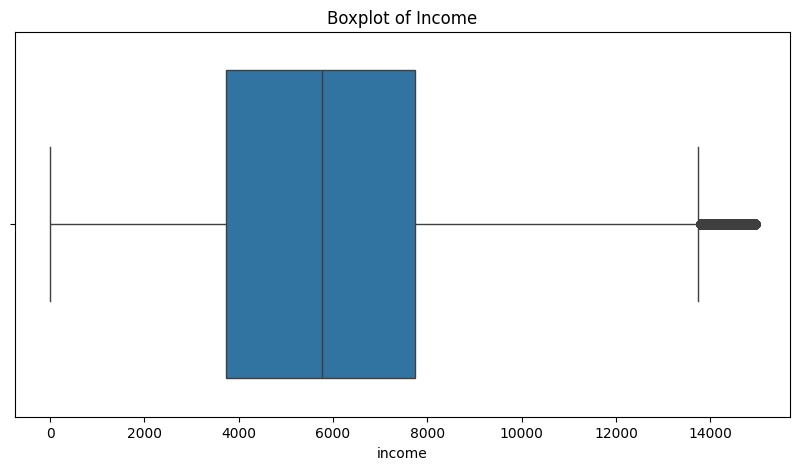

In [50]:
# Visualize the distribution of income and detect outliers using a boxplot
plt.figure(figsize=(10,5))
sns.boxplot(x=df['income'])
plt.title("Boxplot of Income")
plt.xlabel("income")
plt.show()

In [51]:
# Remove outliers using the IQR method
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['income'] >= lower) & (df['income'] <= upper)]


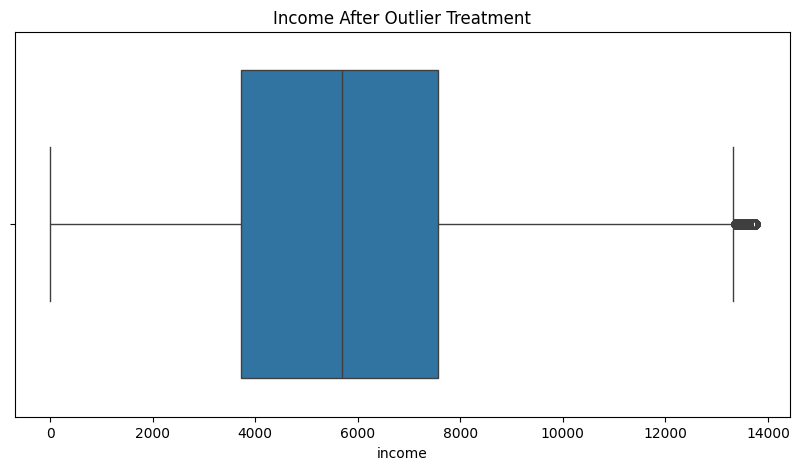

In [52]:
# Visualize income distribution after outlier treatment
plt.figure(figsize=(10,5))
sns.boxplot(x=df['income'])
plt.title("Income After Outlier Treatment")
plt.xlabel("income")
plt.show()

In [13]:
# Convert categorical variables into numerical variables
df = pd.get_dummies(df, drop_first=True)

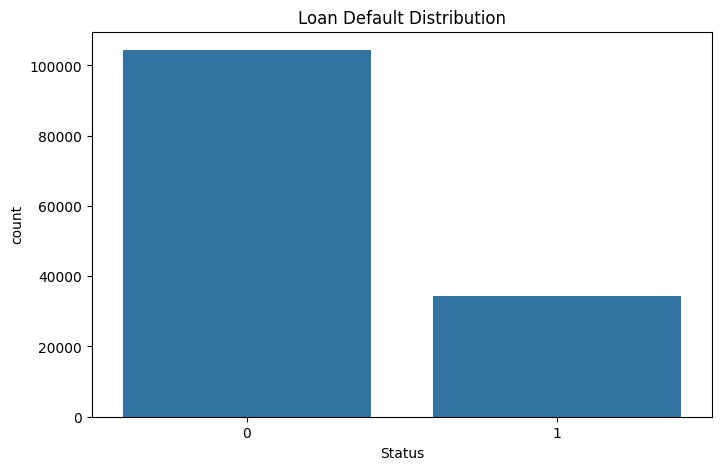

In [53]:
# Visualize the distribution of loan default status
plt.figure(figsize=(8,5))
sns.countplot(x='Status', data=df)
plt.title('Loan Default Distribution')
plt.show()


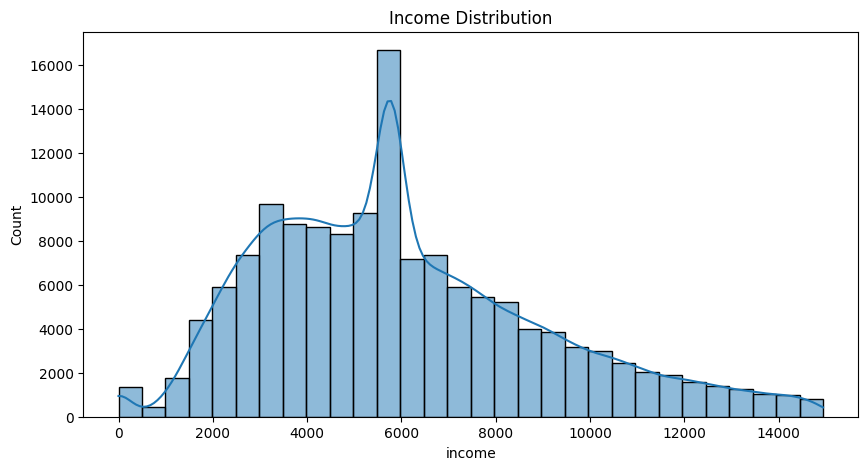

In [15]:
# Visualize the distribution of income
plt.figure(figsize=(10,5))
sns.histplot(df['income'], bins=30, kde=True)
plt.title('Income Distribution')
plt.show()


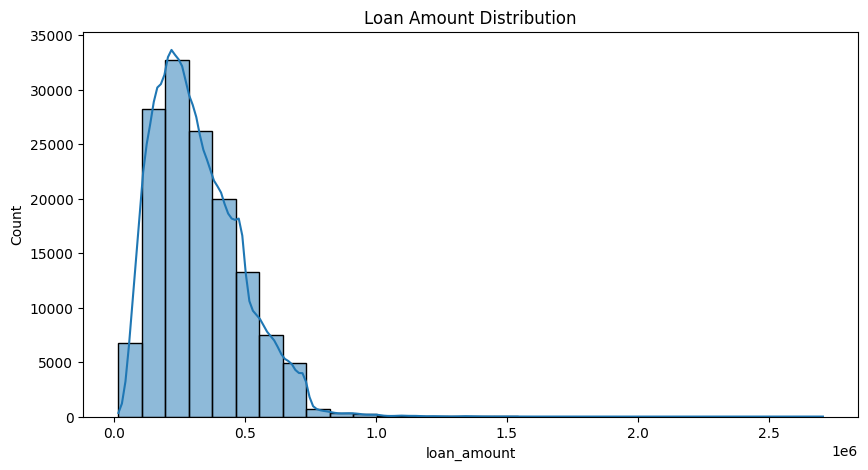

In [16]:
# Visualize loan amount distribution
plt.figure(figsize=(10,5))
sns.histplot(df['loan_amount'], bins=30, kde=True)
plt.title('Loan Amount Distribution')
plt.show()


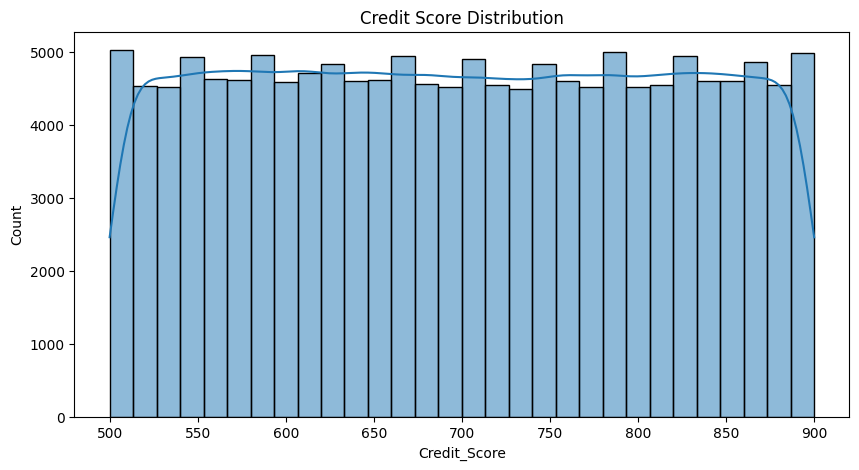

In [17]:
# Visualize credit score distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Credit_Score'], bins=30, kde=True)
plt.title('Credit Score Distribution')
plt.show()


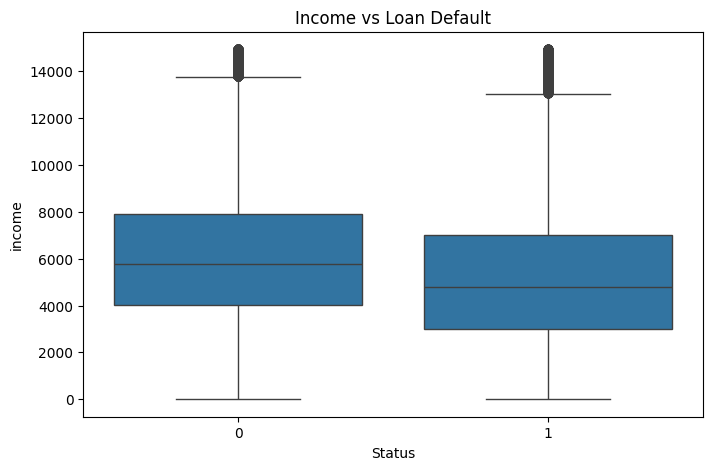

In [18]:
# Compare income distribution by loan status (default vs non-default)
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='income', data=df)
plt.title('Income vs Loan Default')
plt.show()


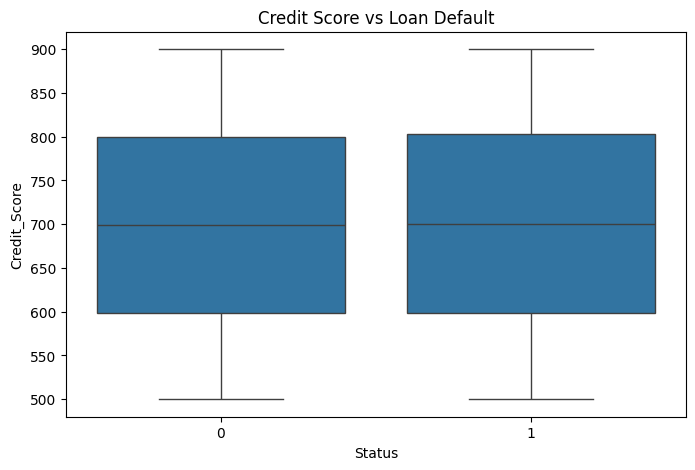

In [19]:
# Compare credit score distribution by loan status (default vs non-default)
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='Credit_Score', data=df)
plt.title('Credit Score vs Loan Default')
plt.show()


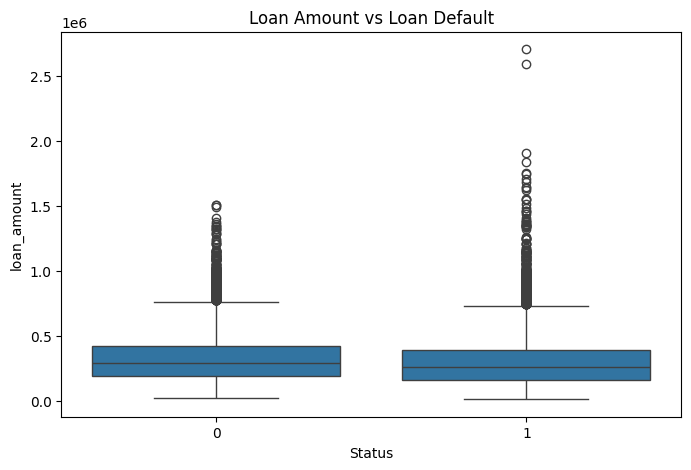

In [54]:
# Compare loan amount distribution by loan status (default vs non-default)
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='loan_amount', data=df)
plt.title('Loan Amount vs Loan Default')
plt.show()


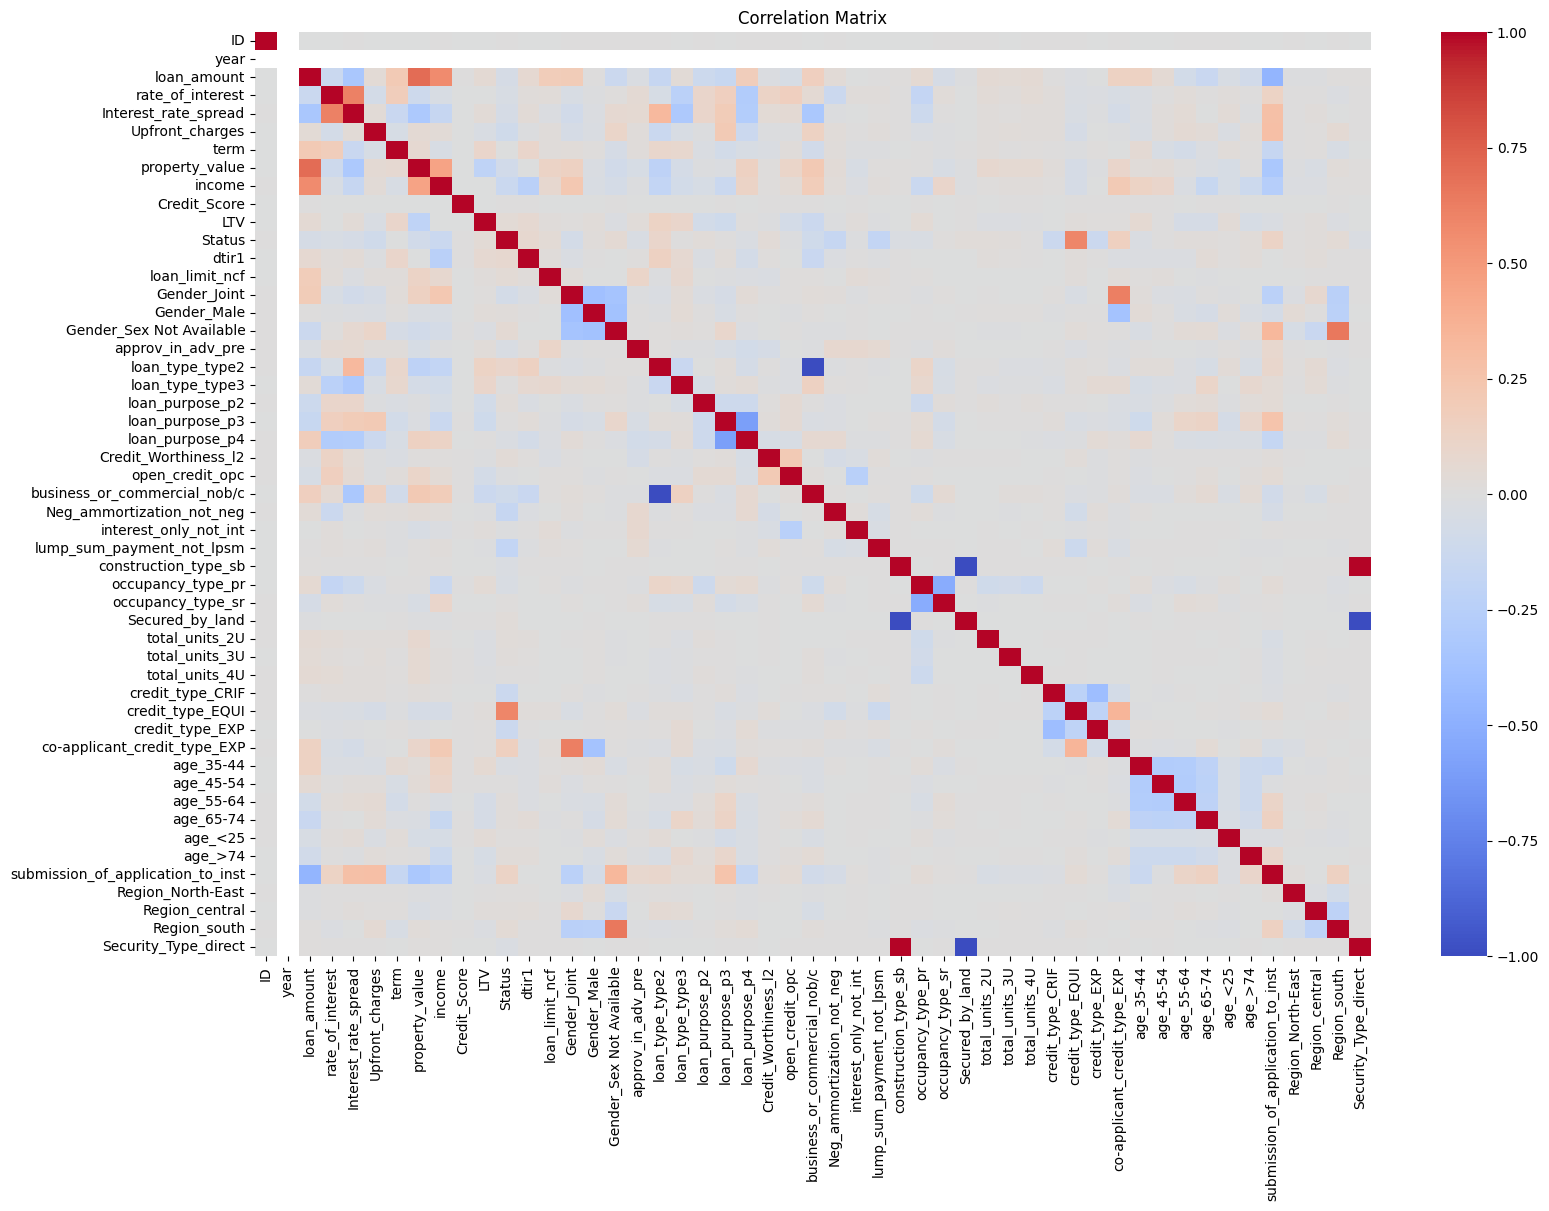

In [21]:
# Correlation heatmap
corr_matrix = df.corr()
plt.figure(figsize=(18,12))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


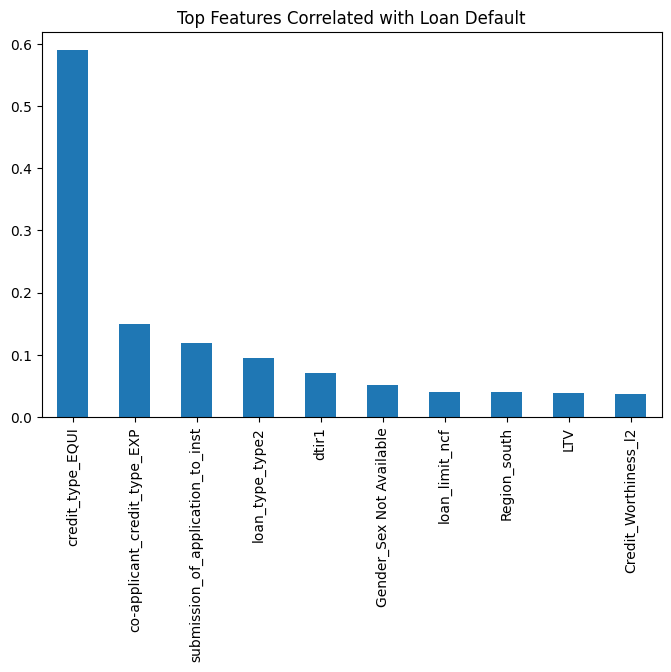

In [55]:
# Top features correlated with loan default
corr_target = corr_matrix['Status'].sort_values(ascending=False)
top_corr = corr_target[1:11]
plt.figure(figsize=(8,5))
top_corr.plot(kind='bar')
plt.title('Top Features Correlated with Loan Default')
plt.show()


In [23]:
# Split features (X) and target (y)
X = df.drop('Status', axis=1)
y = df['Status']

In [56]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# Train Logistic Regression model
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)


LogisticRegression()

In [27]:
# Make predictions
y_pred = lr_model.predict(X_test_scaled)

In [57]:
# Evaluate model performance
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8724075584074875
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     21218
           1       0.93      0.53      0.67      6989

    accuracy                           0.87     28207
   macro avg       0.90      0.76      0.80     28207
weighted avg       0.88      0.87      0.86     28207



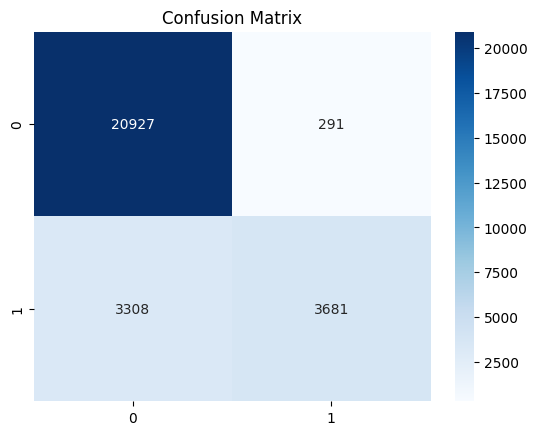

In [29]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


In [30]:
# ROC curve & AUC for Logistic Regression
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

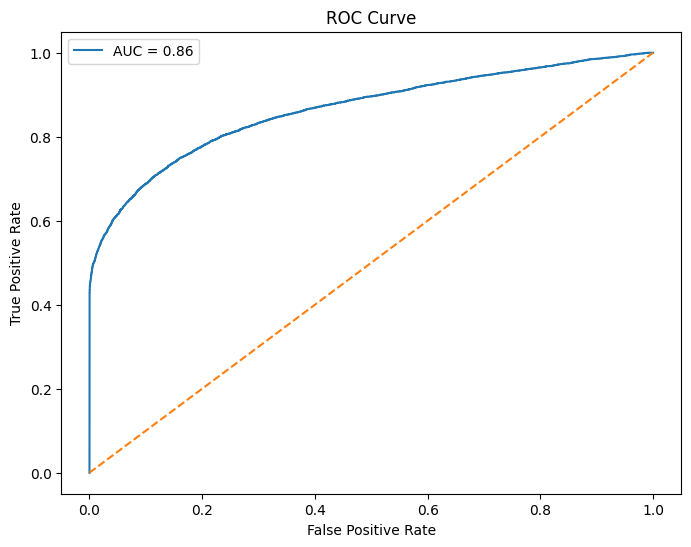

In [31]:
# ROC Curve - Logistic Regression
plt.figure(figsize=(8,6))
# Đường ROC của model
plt.plot(fpr_lr,
        tpr_lr,
        label=f'AUC = {auc_lr:.2f}')
# Đường baseline (model random)
plt.plot([0,1], [0,1], linestyle='--')
# Nhãn trục
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# Tiêu đề
plt.title("ROC Curve")
plt.legend()
plt.show()


In [32]:
# Feature importance from Logistic Regression coefficients
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})
importance = importance.sort_values(by='Coefficient', ascending=False)
importance


,Feature,Coefficient
36,credit_type_EQUI,3.373259
10,LTV,0.698896
45,submission_of_application_to_inst,0.639614
2,loan_amount,0.219493
20,loan_purpose_p3,0.190396
12,loan_limit_ncf,0.149592
19,loan_purpose_p2,0.138989
41,age_55-64,0.116174
17,loan_type_type2,0.108796
40,age_45-54,0.104571


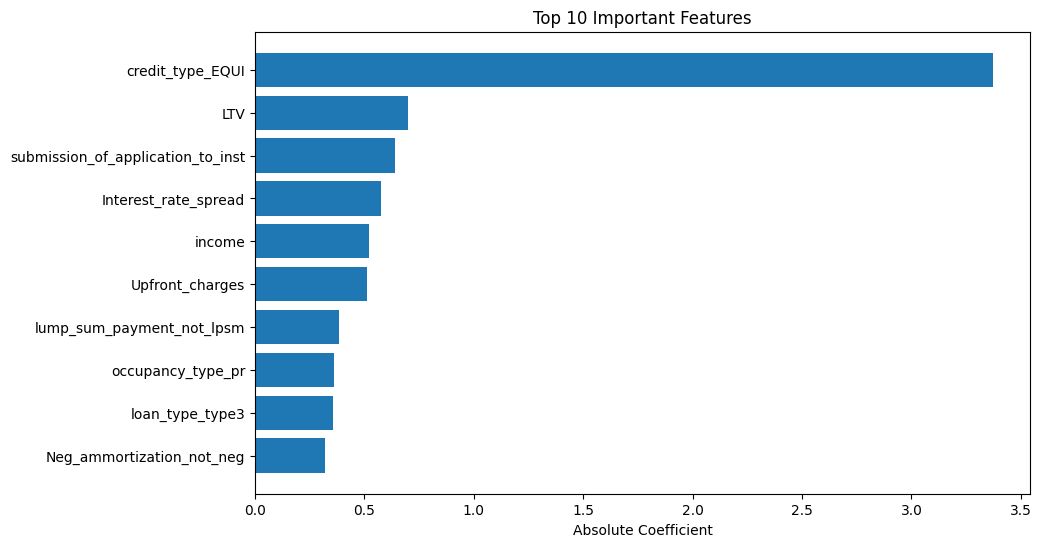

In [60]:
import matplotlib.pyplot as plt
# Plot top 10 important features
plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Abs_Coefficient'])
# Invert y-axis to show highest importance on top
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.xlabel("Absolute Coefficient")
plt.show()

In [35]:
# Train Random Forest model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)


RandomForestClassifier()

In [36]:
# Make predictions with Random Forest
rf_pred = rf_model.predict(X_test)

In [37]:
# Evaluate Random Forest model
print('Accuracy:', accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21218
           1       1.00      1.00      1.00      6989

    accuracy                           1.00     28207
   macro avg       1.00      1.00      1.00     28207
weighted avg       1.00      1.00      1.00     28207



In [38]:
# ROC curve & AUC for Random Forest
rf_prob = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
auc_rf = roc_auc_score(y_test, rf_prob)

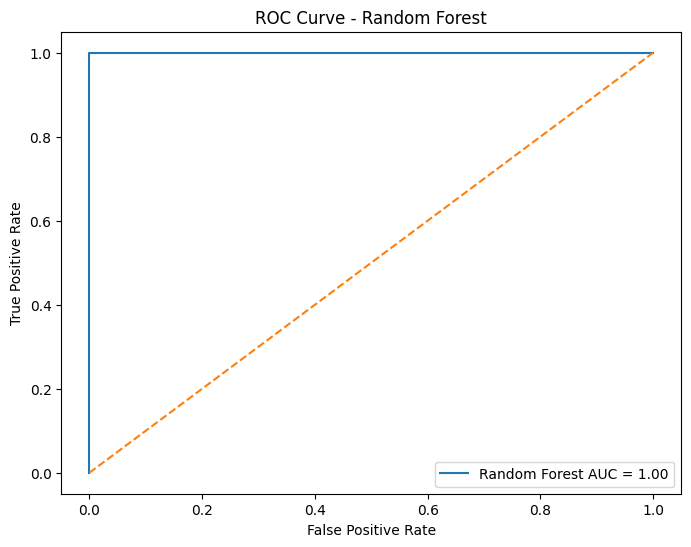

In [39]:
# ROC curve (model)
plt.figure(figsize=(8,6))
plt.plot(fpr_rf,
         tpr_rf,
         label=f'Random Forest AUC = {auc_rf:.2f}')
# Random baseline
plt.plot([0,1], [0,1], linestyle='--')
# Axis labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# Title
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [40]:
# Feature importance from Random Forest
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

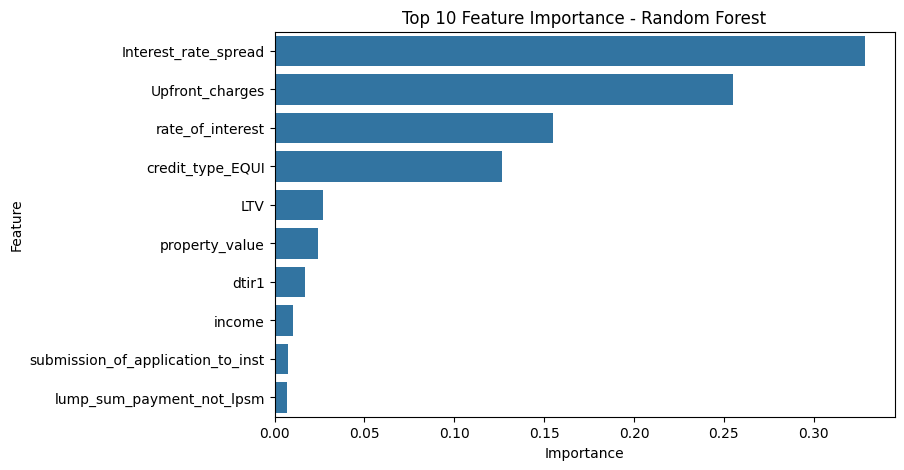

In [41]:
# Top 10 feature importance - Random Forest
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_rf
)

plt.title("Top 10 Feature Importance - Random Forest")

plt.show()

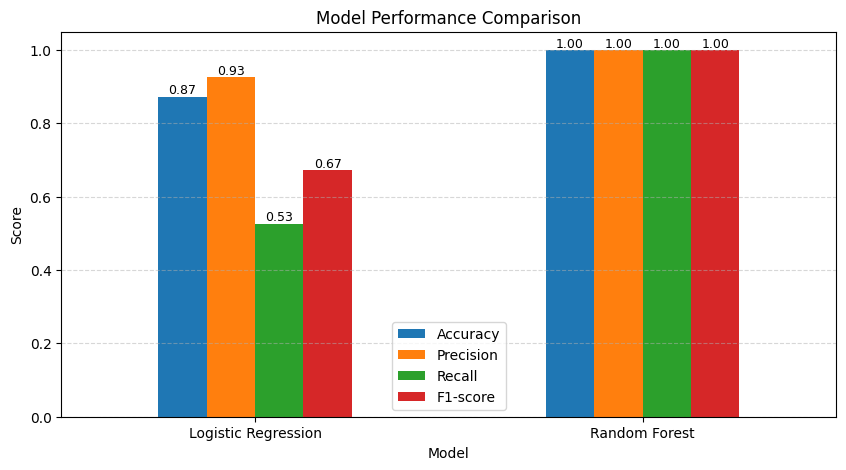

In [61]:
# Compare model performance and visualize it
ax = comparison.set_index('Model').plot(kind='bar', figsize=(10,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
# Add grid for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.5)
# Show value on each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.legend()
plt.show()